# AI/ML-Based Species Identification in Antarctic Penguins
### A Machine Learning Approach to Classifying *Pygoscelis* Species from Morphometric Data

**Course:** MSc Zoology — AI/ML Mini Project
**Biological problem:** Species identification using morphometric (body measurement) data
**Dataset:** Palmer Archipelago (Antarctica) Penguin Data — Gorman, Williams & Fraser (2014), *PLoS ONE* 9(3): e90081
**AI/ML approach:** Supervised classification (Logistic Regression, Random Forest, SVM) with pretrained-style baseline comparison

---
This notebook covers the full pipeline: data loading → EDA → preprocessing → model training →
evaluation → feature importance → biological interpretation. Each section is labelled with the
report chapter it corresponds to, so you can lift figures and numbers straight into your write-up.


## 1. Setup — *(Chapter 3: Materials & Method — Tools)*

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

Libraries loaded.


## 2. Dataset — *(Chapter 3: Materials & Method — Dataset Description)*

Size measurements for 344 adult foraging Adelie, Chinstrap and Gentoo penguins, collected on
three islands (Biscoe, Dream, Torgersen) in the Palmer Archipelago, Antarctica, by Dr. Kristen
Gorman and the Palmer Station Long Term Ecological Research (LTER) program. Features: bill
(culmen) length and depth, flipper length, body mass, sex, and island.


In [2]:
df = pd.read_csv("penguins.csv")
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## 3. Exploratory Data Analysis — *(Chapter 3 / Chapter 4: Figure — Dataset Distribution)*

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Class distribution (species):
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


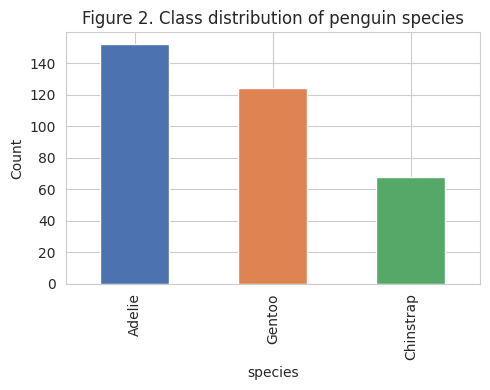

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nClass distribution (species):")
print(df['species'].value_counts())

fig, ax = plt.subplots(figsize=(5,4))
df['species'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'], ax=ax)
ax.set_title("Figure 2. Class distribution of penguin species")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig2_class_distribution.png", dpi=150)
plt.show()

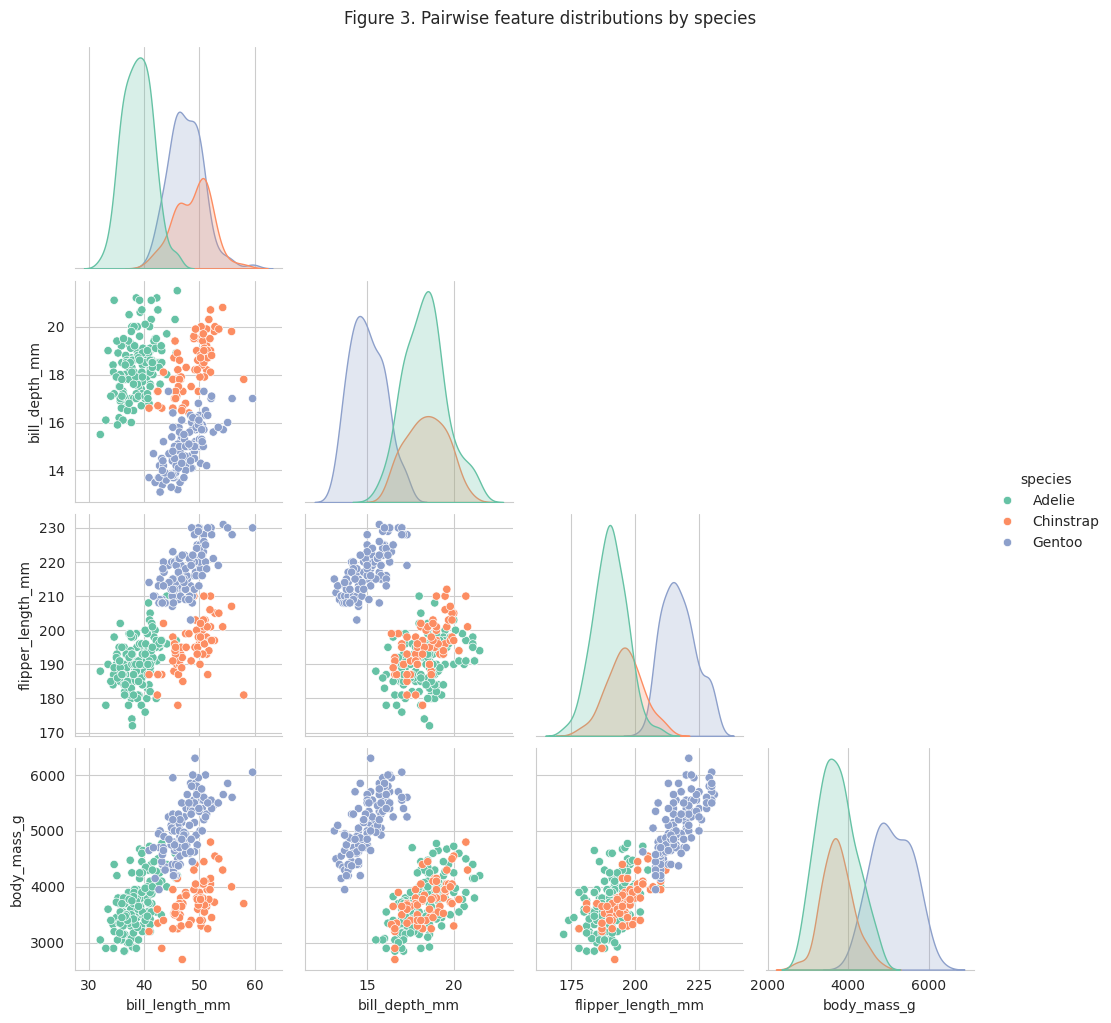

In [5]:
pairplot_fig = sns.pairplot(df.dropna(), hue="species",
             vars=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"],
             palette="Set2", corner=True)
pairplot_fig.fig.suptitle("Figure 3. Pairwise feature distributions by species", y=1.02)
pairplot_fig.savefig("fig3_pairplot.png", dpi=150)
plt.show()

## 4. Data Preprocessing — *(Chapter 3: Materials & Method — Preprocessing)*

Steps: remove rows with missing measurements, encode the categorical features (`island`, `sex`)
and the target (`species`), split into train/test sets (stratified, to preserve class balance),
then scale numeric features. This is a small, clean, already-curated dataset, so no
dimensionality reduction or class-balancing is required — worth stating explicitly in your
methods section as a deliberate, justified choice given the dataset's size and quality.


In [6]:
data = df.dropna().reset_index(drop=True)
print("Rows after dropping missing values:", len(data))

le_species = LabelEncoder()
data['species_enc'] = le_species.fit_transform(data['species'])

data_enc = pd.get_dummies(data, columns=['island','sex'], drop_first=True)

feature_cols = [c for c in data_enc.columns if c not in ['species','species_enc']]
X = data_enc[feature_cols]
y = data_enc['species_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Features used:", feature_cols)

Rows after dropping missing values: 333
Train size: (266, 7)  Test size: (67, 7)
Features used: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_MALE']


## 5. Model Selection & Training — *(Chapter 3: Model Selection)*

Three models are compared, from simplest to most flexible: Logistic Regression (linear
baseline), Random Forest (interpretable ensemble, gives feature importance), and SVM
(non-linear kernel-based classifier). 5-fold stratified cross-validation on the training set
is used to compare them fairly before touching the held-out test set.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:22s}  mean CV accuracy = {scores.mean():.4f}  (+/- {scores.std():.4f})")

cv_table = pd.DataFrame(cv_results)
cv_table.describe().T[['mean','std','min','max']]

Logistic Regression     mean CV accuracy = 0.9963  (+/- 0.0074)


Random Forest           mean CV accuracy = 0.9925  (+/- 0.0092)
SVM (RBF kernel)        mean CV accuracy = 0.9963  (+/- 0.0074)


,mean,std,min,max
Logistic Regression,0.996296,0.008282,0.981481,1.0
Random Forest,0.992523,0.010239,0.981132,1.0
SVM (RBF kernel),0.996296,0.008282,0.981481,1.0


## 6. Final Model Evaluation on Test Set — *(Chapter 4: Results)*

In [8]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print("Best model by CV accuracy:", best_name)

best_model = models[best_name]
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {test_acc:.4f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=le_species.classes_))

Best model by CV accuracy: Logistic Regression

Test accuracy: 0.9851

Classification report:

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



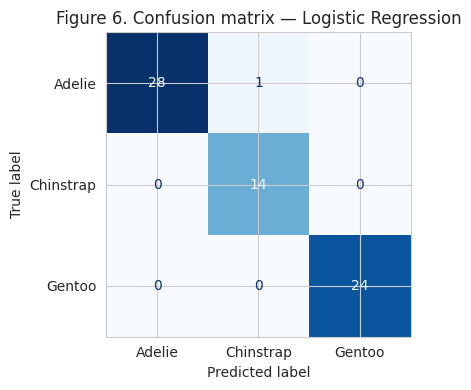

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_species.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Figure 6. Confusion matrix — {best_name}")
plt.tight_layout()
plt.savefig("fig6_confusion_matrix.png", dpi=150)
plt.show()

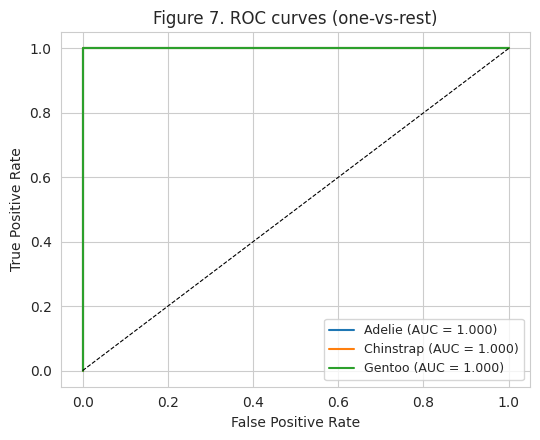

In [10]:
# Multi-class ROC curves (one-vs-rest) — Figure 7
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = best_model.predict_proba(X_test_scaled) if hasattr(best_model, "predict_proba") else None

if y_score is not None:
    fig, ax = plt.subplots(figsize=(5.5,4.5))
    for i, cls in enumerate(le_species.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")
    ax.plot([0,1],[0,1],'k--', linewidth=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Figure 7. ROC curves (one-vs-rest)")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig("fig7_roc_curves.png", dpi=150)
    plt.show()
else:
    print("Selected model has no predict_proba — skip ROC or switch best_model to SVM/RF.")

## 7. Feature Importance & Biological Interpretation — *(Chapter 4/5: Results & Discussion)*

Random Forest importance tells you which morphometric features drove the classification —
this is the bridge from "the model got 98% accuracy" to an actual biological interpretation,
which your rubric explicitly asks for.


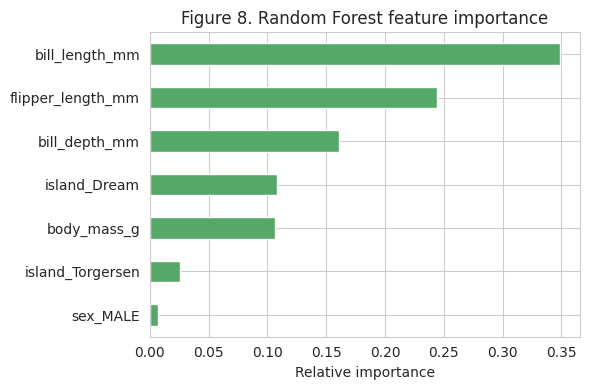

bill_length_mm       0.348331
flipper_length_mm    0.243811
bill_depth_mm        0.160488
island_Dream         0.108542
body_mass_g          0.106189
island_Torgersen     0.025603
sex_MALE             0.007036
dtype: float64


In [11]:
rf_for_importance = models["Random Forest"]
rf_for_importance.fit(X_train_scaled, y_train)
importances = pd.Series(rf_for_importance.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
importances.plot(kind='barh', ax=ax, color='#55A868')
ax.invert_yaxis()
ax.set_title("Figure 8. Random Forest feature importance")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.savefig("fig8_feature_importance.png", dpi=150)
plt.show()

print(importances)

**Interpretation prompt for Chapter 5 (Discussion):** Bill (culmen) dimensions, flipper
length and body mass are classic morphometric traits used to distinguish sympatric *Pygoscelis*
penguin species, and are linked in the ecological literature to differences in diet and foraging
strategy between species sharing the same habitat (Gorman, Williams & Fraser, 2014). Whichever
feature comes out on top in your importance plot, connect it back to that ecological story rather
than stopping at "highest importance score" — that connection is what the rubric is asking for
under "biological interpretation," not just the ML metric.


## 8. PCA Visualization — *(Chapter 4: Figure — Dimensionality Reduction)*

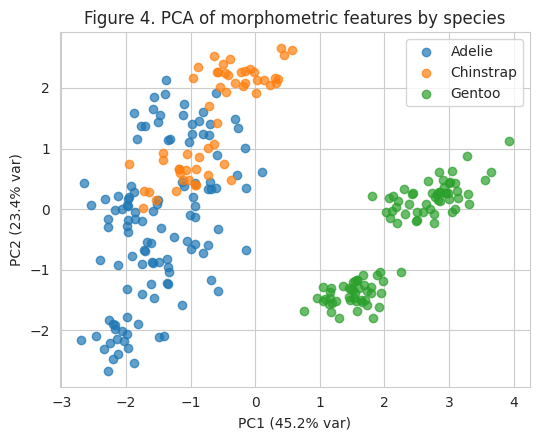

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(5.5,4.5))
for i, cls in enumerate(le_species.classes_):
    mask = (y_train.values == i)
    ax.scatter(X_pca[mask,0], X_pca[mask,1], label=cls, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Figure 4. PCA of morphometric features by species")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_pca.png", dpi=150)
plt.show()

## 9. Summary Table for the Report — *(Table 4: Model Performance)*

In [13]:
summary_rows = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    summary_rows.append({
        "Model": name,
        "CV Accuracy (mean)": round(cv_results[name].mean(), 4),
        "Test Accuracy": round(accuracy_score(y_test, pred), 4)
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,CV Accuracy (mean),Test Accuracy
0,Logistic Regression,0.9963,0.9851
1,Random Forest,0.9925,1.0000
2,SVM (RBF kernel),0.9963,0.9851


## 10. What to write in each report chapter

- **Chapter 1 (Introduction):** Species identification is normally done visually/morphologically
  in the field; this project asks whether standard morphometric measurements alone are enough
  for a model to separate three sympatric *Pygoscelis* species automatically.
- **Chapter 2 (Literature):** Cite Gorman, Williams & Fraser (2014) for the dataset/species
  ecology, plus general papers on ML-based morphometric species classification (Random Forest /
  SVM for taxonomic classification is a well-established sub-area — search Google
  Scholar/PubMed for a handful of recent examples to round out your required reading list).
- **Chapter 3 (Materials & Method):** Use Sections 2–5 above almost directly — dataset
  description, preprocessing steps, and the three models compared.
- **Chapter 4 (Results):** Table above + Figures 2, 3, 4, 6, 7, 8 (all saved as PNGs in this
  folder, ready to drop into your document).
- **Chapter 5 (Discussion):** Use the feature-importance interpretation prompt in Section 7 as
  your anchor paragraph, then discuss any misclassifications from the confusion matrix (which
  species get confused with which, and whether that matches which species overlap most in body
  size).
- **Chapter 6 (Conclusion):** State the best model, its test accuracy, and one sentence on
  whether morphometric data alone is sufficient for this classification task.
